# State-Transition Analysis of Annotated Coding Sessions

Builds one transition graph per participant (and group-level graphs for
`Condition` and `Cohort`) from the annotation log.

**Design choices, please read before running:**
- Graph nodes use the **full Master Code** (`READ_QUESTION`, `DEBUG_VIA_LLM`, ...),
  not the shorthand alias. Your alias list currently has `WC` shared by three
  different states and `DB` shared by two - using shorthand would silently
  merge those states in the graph. If you want short labels *purely for display*,
  relabel manually after the fact; don't feed collapsed aliases into the analysis.
- Grouping columns (`Participant ID`, `Cohort`, `Condition`, `Session`, `Question`,
  `Question Type`) are **forward-filled** on load, since earlier annotation
  passes left them blank on repeat rows within the same block. If your CSV
  already has every row fully populated, this step is a no-op.
- A "sequence" = one continuous ordered run of `State Code` values for one
  `Participant ID` + `Question` (change the `SEQUENCE_KEY` below if you'd
  rather sequence per whole `Session`, or per whole participant).

In [3]:
%pip install networkx

  Obtaining dependency information for networkx from https://files.pythonhosted.org/packages/9e/c9/b2622292ea83fbb4ec318f5b9ab867d0a28ab43c5717bb85b0a5f6b3b0a4/networkx-3.6.1-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 2.3 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import os
from pathlib import Path

BASE_DIR = Path.cwd()

CSV_PATH = BASE_DIR / "annotations" / "annotation_log.csv"
OUT_DIR = BASE_DIR / "mnt"/ "user-data" / "outputs" / "graphs"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# Which columns define one continuous sequence.
# Default: per participant, per question (recommended).
SEQUENCE_KEY = ["Participant ID", "Session", "Question"]

## 1. Load and clean the data

In [25]:
df = pd.read_csv(CSV_PATH)

# Strip stray whitespace from headers/values
df.columns = [c.strip() for c in df.columns]
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype(str).str.strip().replace({"nan": np.nan, "": np.nan})

# --- Forward-fill the grouping/context columns (handles the "blank repeat row" format) ---
FFILL_COLS = ["Participant ID", "Cohort", "Condition", "Session", "Question",
              "Question Type", "Coder ID"]
for col in FFILL_COLS:
    if col in df.columns:
        df[col] = df[col].ffill()

# Drop fully-empty rows (e.g. spacer rows between blocks)
df = df.dropna(subset=["State Code"]).reset_index(drop=True)

print(f"Loaded {len(df)} rows, {df['Participant ID'].nunique()} participants.")
df.head(10)

Loaded 935 rows, 9 participants.


/var/folders/qb/b9m6qf9j7vz76376lk2jvqfw0000gp/T/ipykernel_53970/3939141880.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,Participant ID,Cohort,Condition,Session,Question,Question Type,Event Seq #,State Code,Tool Used,Start Time,End Time,Duration (sec),Artifact Type,Verification (Y/N),Trigger,Raw Note,Coder ID
0,S15,4th_year,with_AI,S1,Q1,NaN,1.0,READ_QUESTION,NaN,0:00:09,0:00:12,3.0,none,N,task_start,READ,C1
1,S15,4th_year,with_AI,S1,Q1,NaN,1.0,ASK_AI_QUESTION,ChatGPT,0:00:18,0:02:05,107.0,none,N,self_initiated,Asked ChatGPT for a complete REST API,C1
2,S15,4th_year,with_AI,S1,Q1,NaN,1.0,READ_LLM_OUTPUT,NaN,0:02:05,0:02:40,35.0,NaN,N,self_initiated,Read llm output,C1
3,S15,4th_year,with_AI,S1,Q1,NaN,1.0,ENV_SETUP,Spring Initializer,00:02:40,00:03:17,37.0,NaN,N,self_initiated,open sprint initilizer and set the variables a...,C1
4,S15,4th_year,with_AI,S1,Q1,NaN,2.0,READ_LLM_OUTPUT,NaN,00:03:17,00:03:21,4.0,NaN,N,AI_instruction,NaN,C1
5,S15,4th_year,with_AI,S1,Q1,NaN,2.0,ENV_SETUP,Spring Initializer,00:03:21,00:04:27,66.0,NaN,N,AI_instruction,genera,C1
6,S15,4th_year,with_AI,S1,Q1,NaN,3.0,READ_LLM_OUTPUT,NaN,00:04:27,00:05:38,71.0,NaN,N,self_initiated,NaN,C1
7,S15,4th_year,with_AI,S1,Q1,NaN,3.0,ENV_SETUP,Intellij,00:05:38,00:06:19,41.0,NaN,N,AI_instruction,NaN,C1
8,S15,4th_year,with_AI,S1,Q1,NaN,NaN,READ_LLM_OUTPUT,NaN,00:06:19,00:06:23,4.0,NaN,N,self_initiated,NaN,C1
9,S15,4th_year,with_AI,S1,Q1,NaN,NaN,ENV_SETUP,"PhpMyAdmin, Intellij",00:06:23,00:07:12,49.0,NaN,N,self_initiated,NaN,C1


## 2. Parse time and compute duration where missing

In [27]:
import numpy as np
import pandas as pd

def parse_time_to_sec(t):
    """Parses 'H:MM:SS' or 'M:SS' style strings into total seconds."""
    if pd.isna(t):
        return np.nan
    s = str(t).strip()
    if not s:
        return np.nan
    try:
        parts = [float(p) for p in s.split(":")]
    except ValueError:
        return np.nan
    if len(parts) == 3:
        h, m, sec = parts
    elif len(parts) == 2:
        h, m, sec = 0, parts[0], parts[1]
    else:
        return np.nan
    return h * 3600 + m * 60 + sec

df["start_sec"] = df["Start Time"].apply(parse_time_to_sec)
df["end_sec"]   = df["End Time"].apply(parse_time_to_sec)

# Use given Duration if present & numeric, else compute from start/end
df["Duration (sec)"] = pd.to_numeric(df.get("Duration (sec)"), errors="coerce")
computed = df["end_sec"] - df["start_sec"]
df["duration_sec"] = df["Duration (sec)"].fillna(computed)

In [28]:
bad = df[
    (df["Start Time"].notna() & df["start_sec"].isna()) |
    (df["End Time"].notna() & df["end_sec"].isna())
]
print(bad[["Participant ID", "Event Seq #", "State Code", "Start Time", "End Time"]])

Empty DataFrame
Columns: [Participant ID, Event Seq #, State Code, Start Time, End Time]
Index: []


## 3. Build ordered state sequences (one per Participant x Session x Question)

In [29]:
def build_sequences(df, key_cols):
    # Returns: dict {sequence_id_tuple: [(state, duration_sec), ...]}
    # Assumes rows are already in chronological order within each group;
    # sorts by start_sec as a safety net.
    sequences = {}
    grouped = df.sort_values("start_sec").groupby(key_cols, dropna=False)
    for key, g in grouped:
        seq = list(zip(g["State Code"], g["duration_sec"]))
        sequences[key] = seq
    return sequences

sequences = build_sequences(df, SEQUENCE_KEY)
print(f"Built {len(sequences)} sequences.")
first_key = list(sequences.keys())[0]
print(first_key, "->", sequences[first_key][:6], "...")

Built 154 sequences.
('S10', 'S1', 'Q1') -> [('ASK_AI_QUESTION', 9.0), ('READ_LLM_OUTPUT', 65.0)] ...


## 4. Transition counts & probabilities (Step 3-4 of the method)

For a set of sequences, counts every consecutive `State A -> State B` pair,
then normalizes by total outgoing transitions from each state to get
`P(B|A)`.

In [30]:
def transition_counts(seq_list):
    # seq_list: list of sequences, each a list of (state, duration).
    counts = defaultdict(int)
    for seq in seq_list:
        states = [s for s, _ in seq]
        for a, b in zip(states, states[1:]):
            counts[(a, b)] += 1
    return counts

def transition_probabilities(counts):
    # counts: dict {(a,b): n} -> dict {(a,b): P(b|a)}
    outgoing_totals = defaultdict(int)
    for (a, b), n in counts.items():
        outgoing_totals[a] += n
    probs = {(a, b): n / outgoing_totals[a] for (a, b), n in counts.items()}
    return probs

def avg_durations(seq_list):
    # seq_list: list of sequences -> dict {state: avg_duration_sec}
    totals = defaultdict(list)
    for seq in seq_list:
        for state, dur in seq:
            if pd.notna(dur):
                totals[state].append(dur)
    return {state: np.mean(vals) for state, vals in totals.items() if vals}

## 5. Draw a transition graph

- **Node size** proportional to average time spent in that state.
- **Edge thickness** proportional to transition frequency (count).
- **Edge label** = transition probability P(B|A).

In [31]:
def draw_transition_graph(seq_list, title, save_path=None,
                           min_count=1, figsize=(10, 8), seed=42):
    counts = transition_counts(seq_list)
    counts = {k: v for k, v in counts.items() if v >= min_count}
    if not counts:
        print(f"[skip] no transitions for: {title}")
        return None

    probs = transition_probabilities(counts)
    durations = avg_durations(seq_list)

    G = nx.DiGraph()
    for state, dur in durations.items():
        G.add_node(state, avg_dur=dur)
    for (a, b), n in counts.items():
        G.add_edge(a, b, weight=n, prob=probs[(a, b)])

    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(G, seed=seed, k=1.4)

    max_dur = max(durations.values()) if durations else 1
    node_sizes = [300 + 2200 * (G.nodes[n].get("avg_dur", 0) / max_dur) for n in G.nodes()]

    max_w = max(nx.get_edge_attributes(G, "weight").values())
    edge_widths = [1 + 5 * (G[u][v]["weight"] / max_w) for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                            node_color="#8ecae6", edgecolors="#023047", linewidths=1.2, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)
    nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.6,
                            arrows=True, arrowsize=14, connectionstyle="arc3,rad=0.08", ax=ax)
    edge_labels = {(u, v): f"{d['prob']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, ax=ax)

    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160)
        print(f"saved -> {save_path}")
    plt.show()
    plt.close(fig)
    return G

## 6. One graph per participant (\"per child\")

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S15_transition_graph.png


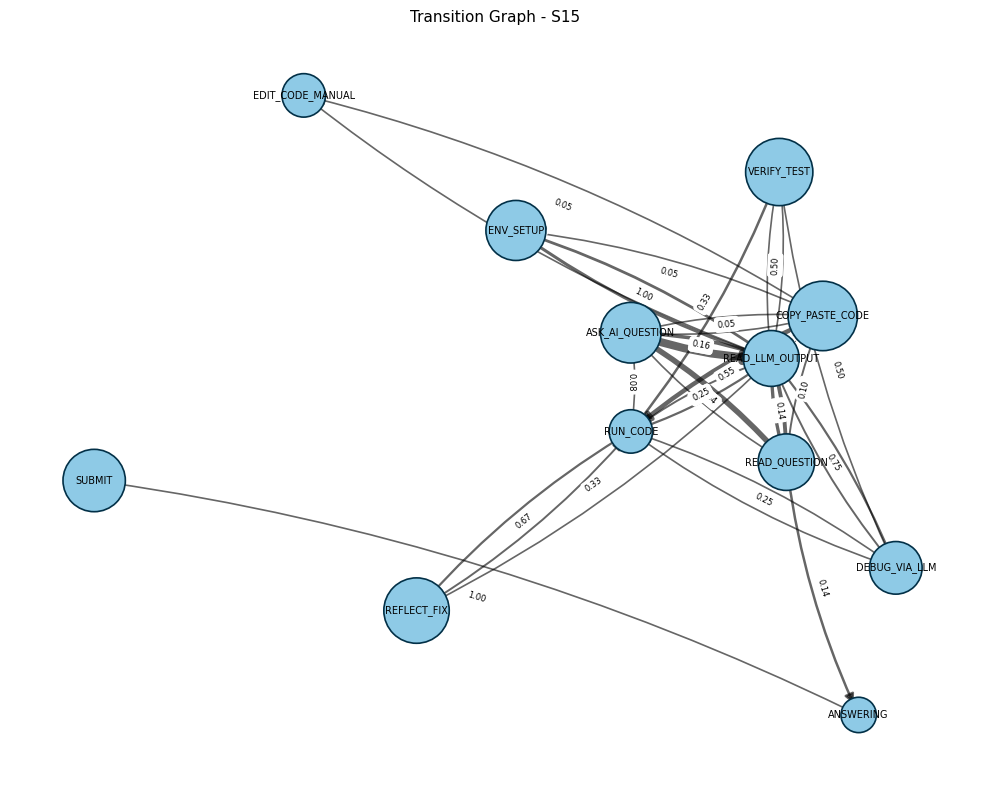

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S3_transition_graph.png


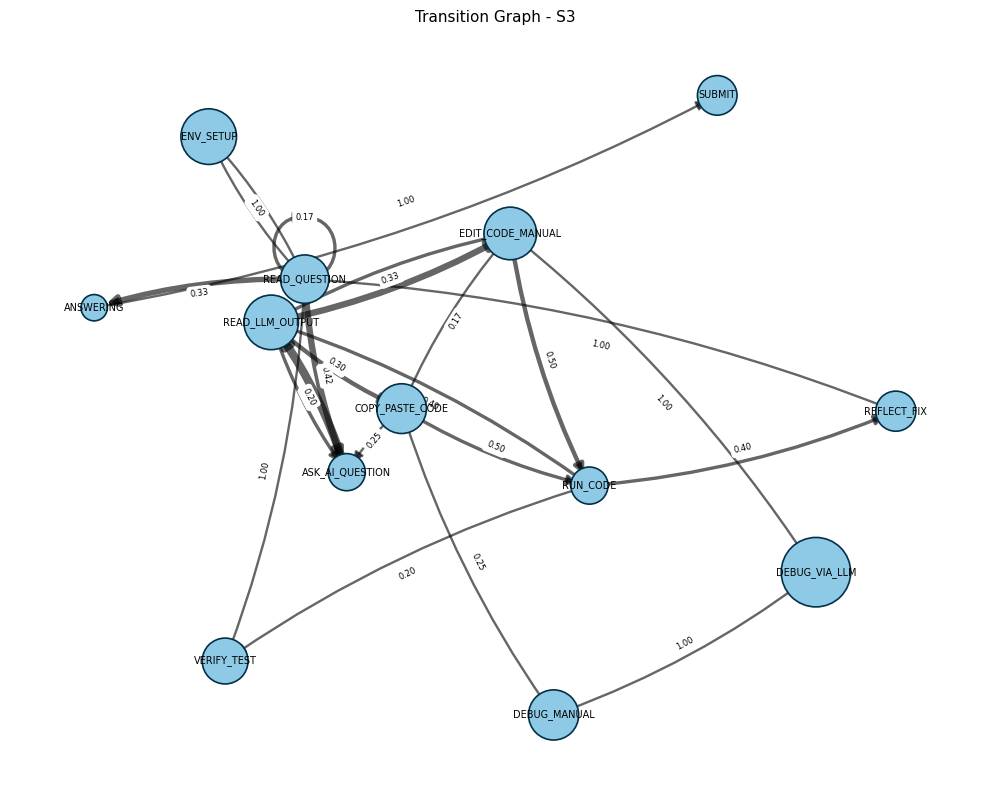

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S2_transition_graph.png


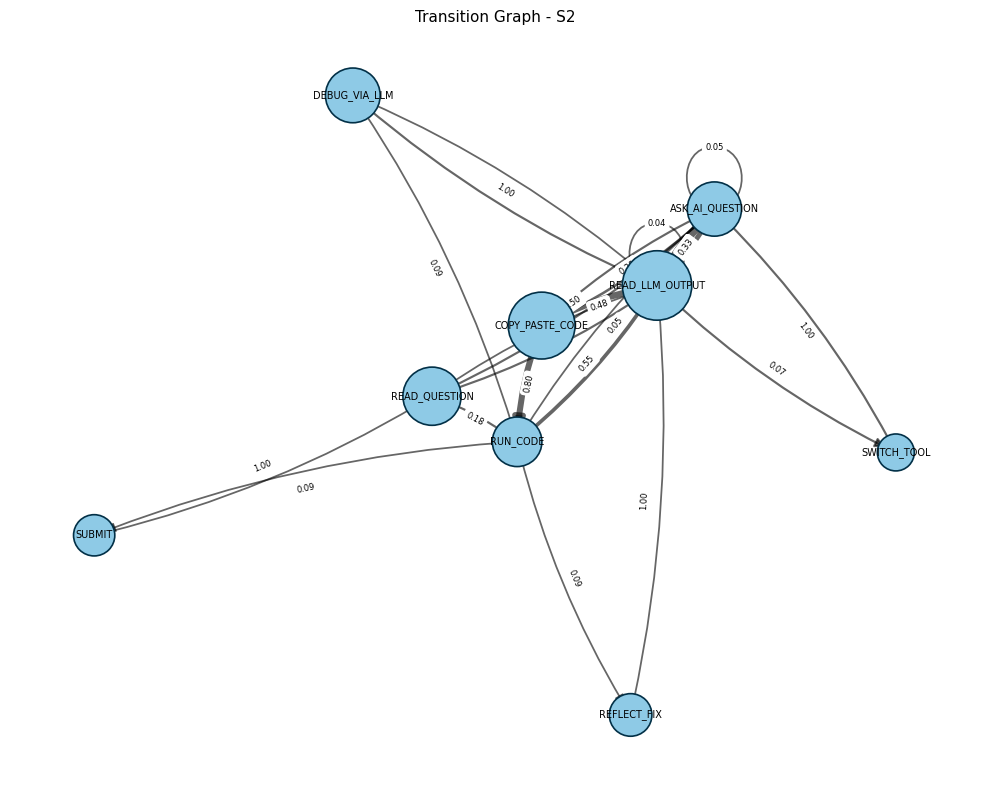

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S18_transition_graph.png


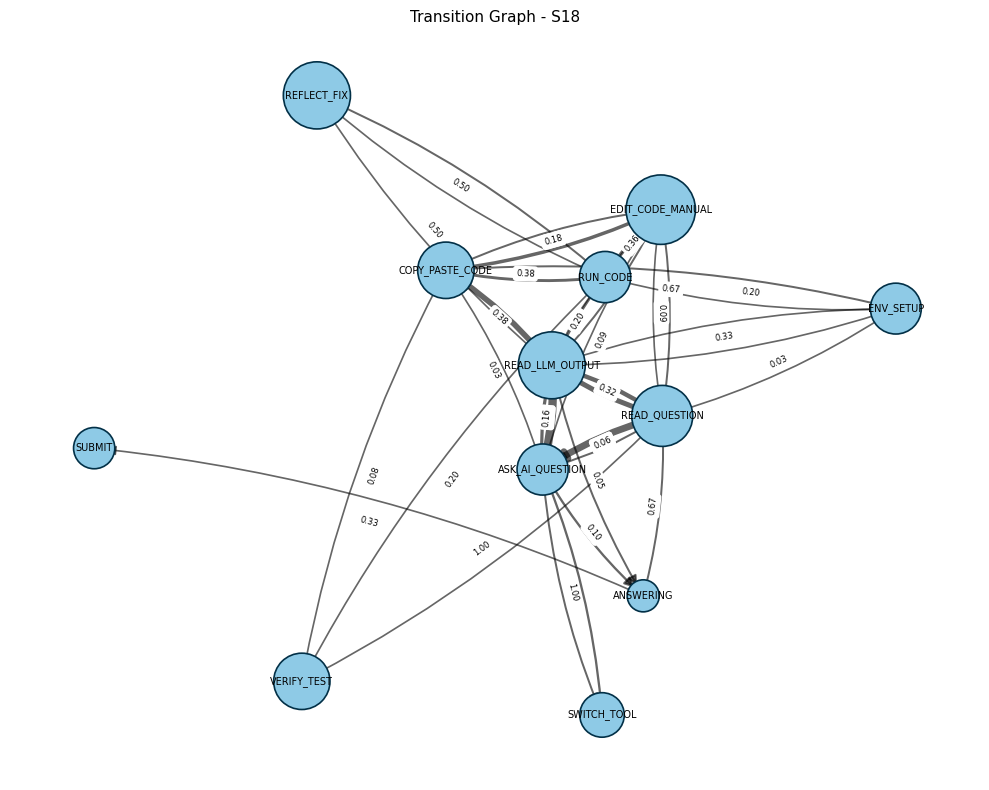

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S10_transition_graph.png


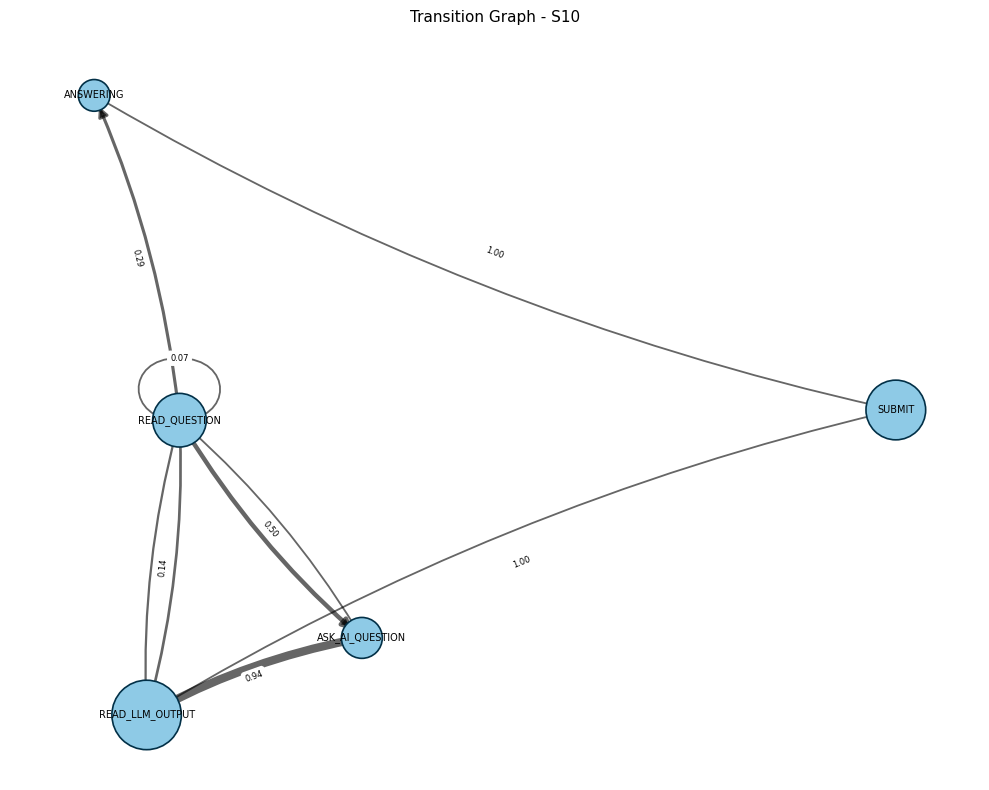

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S16_transition_graph.png


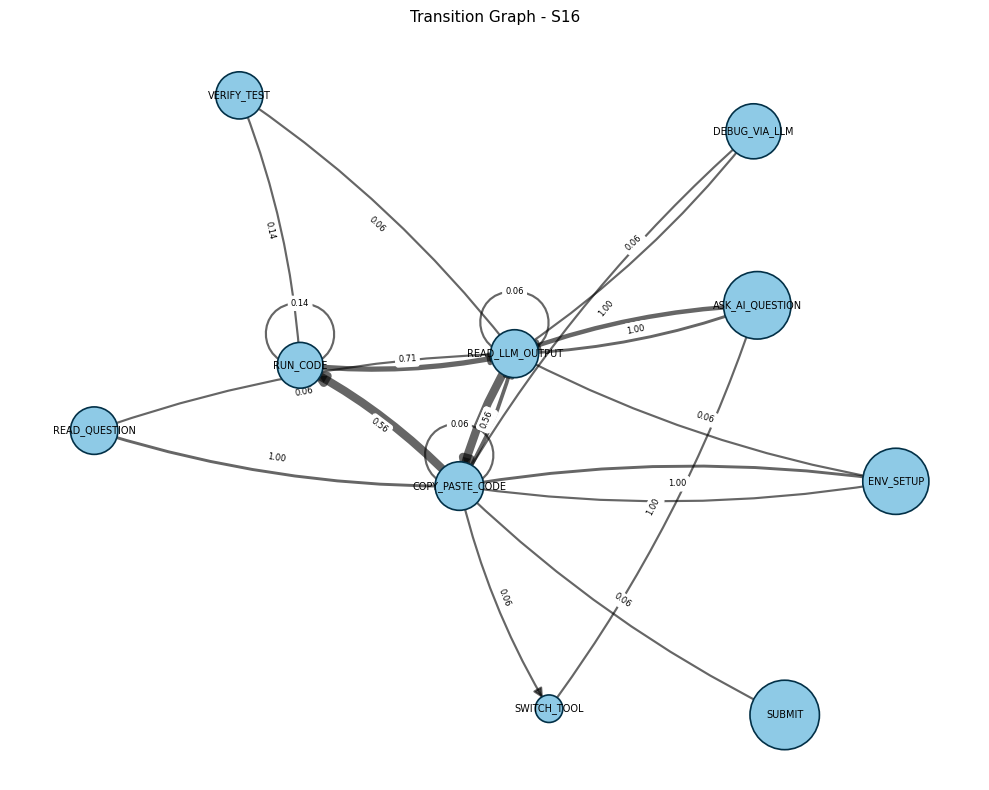

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S6_transition_graph.png


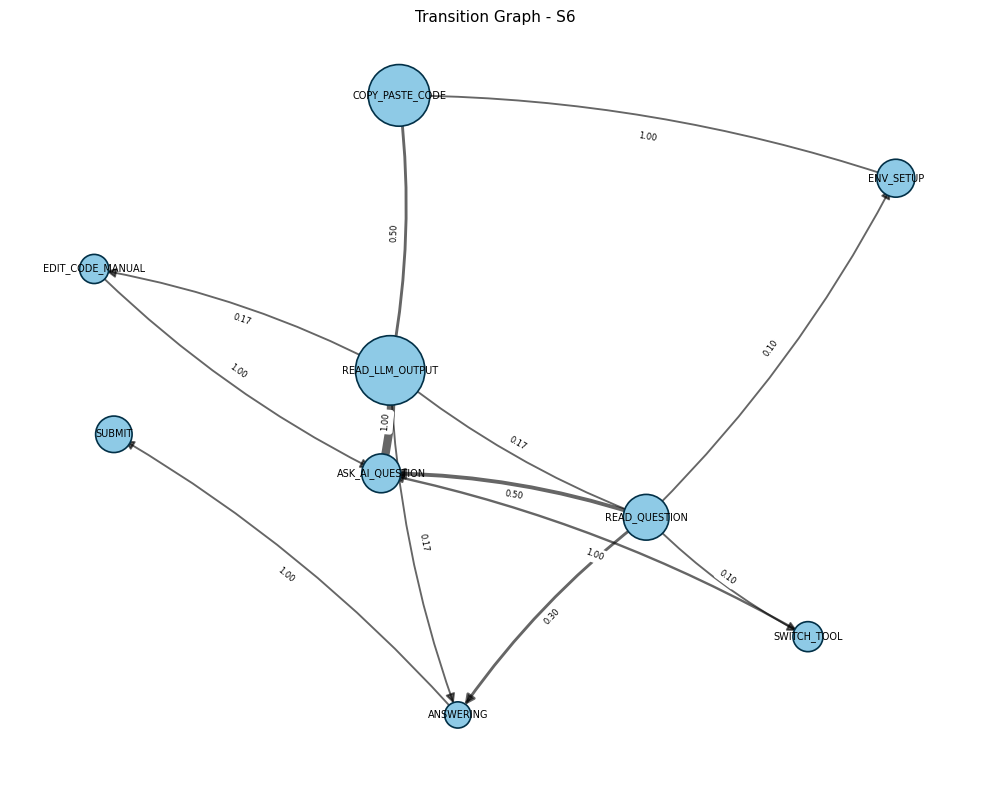

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S9_transition_graph.png


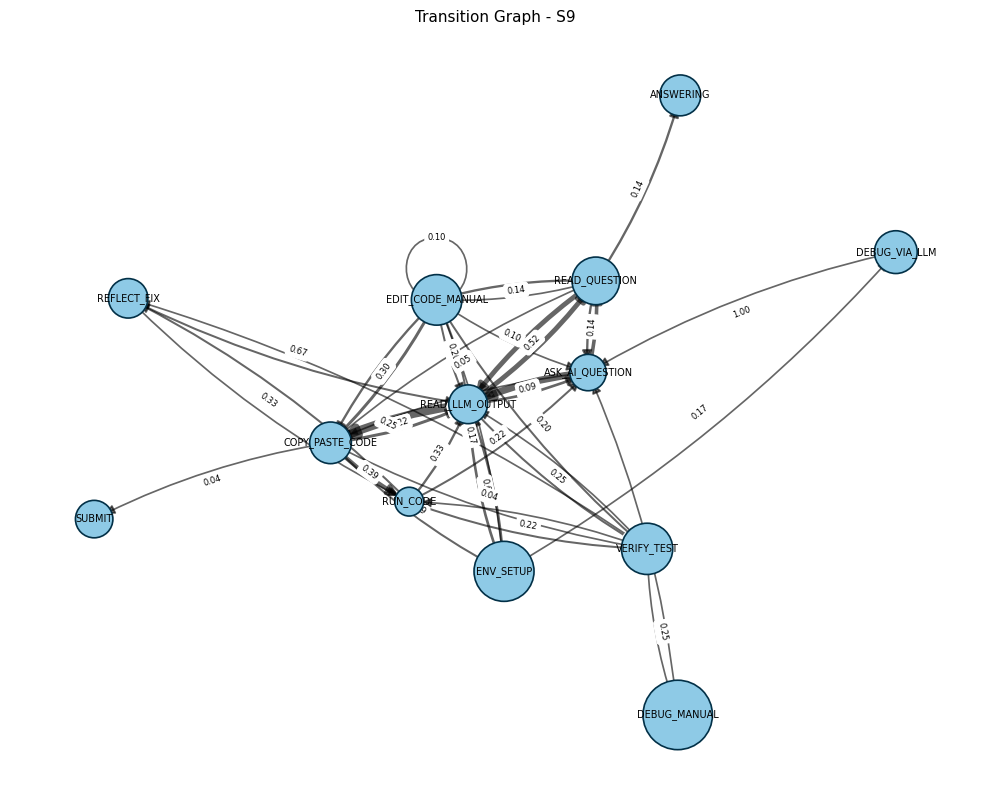

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/S14_transition_graph.png


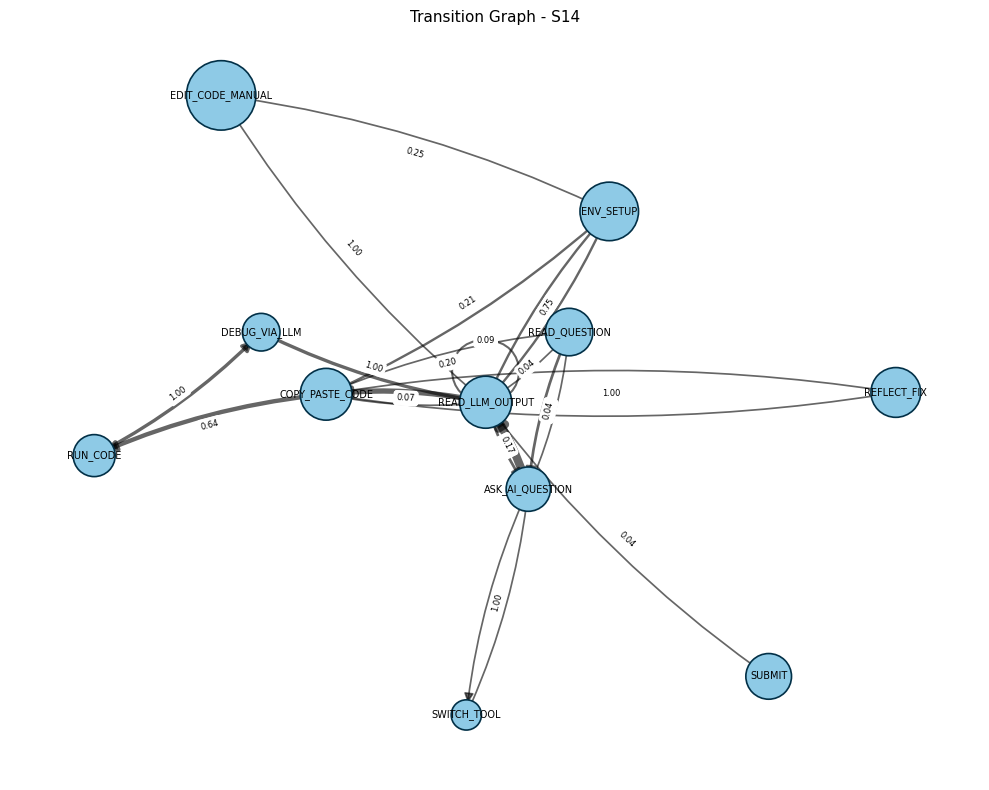

In [32]:
participant_ids = df["Participant ID"].dropna().unique()

participant_graphs = {}
for pid in participant_ids:
    seq_list = [seq for key, seq in sequences.items() if key[0] == pid]
    save_path = os.path.join(OUT_DIR, f"{pid}_transition_graph.png")
    G = draw_transition_graph(seq_list, title=f"Transition Graph - {pid}", save_path=save_path)
    participant_graphs[pid] = G

## 7. Group-level graphs (Condition & Cohort) - Step 7

Aggregates all participants within a group into one combined graph, so you
can compare e.g. `with_AI` vs `without_AI`, or `1st_year` vs `4th_year`,
side by side.

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/GROUP_condition_with_AI.png


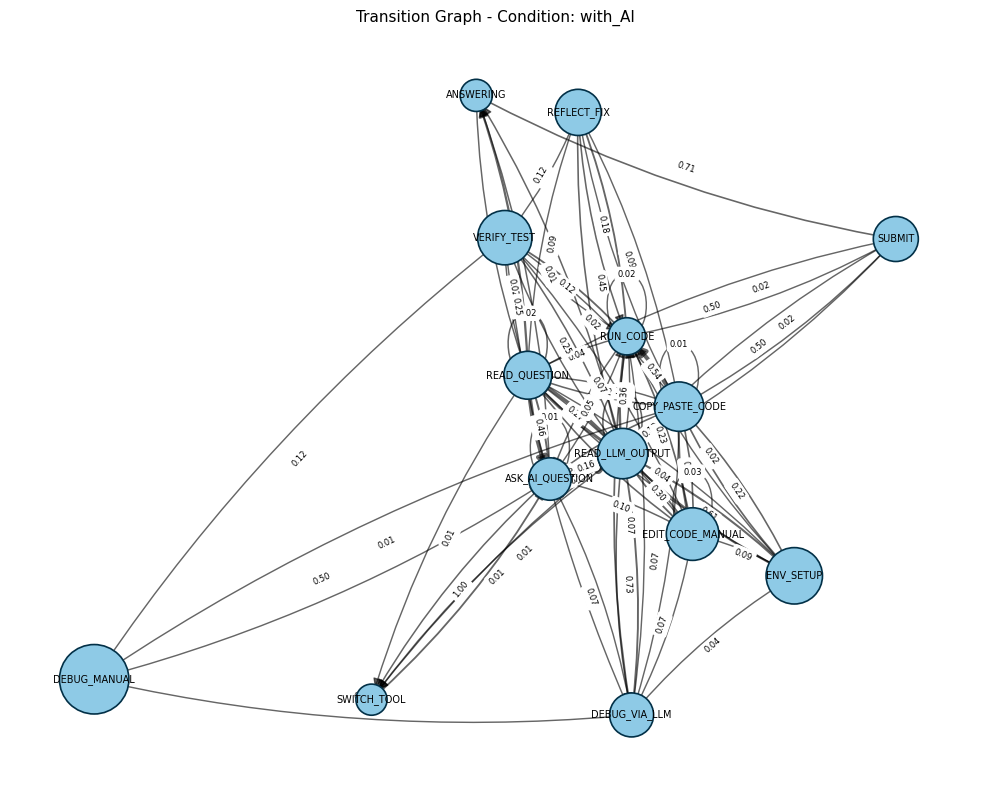

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/GROUP_cohort_4th_year.png


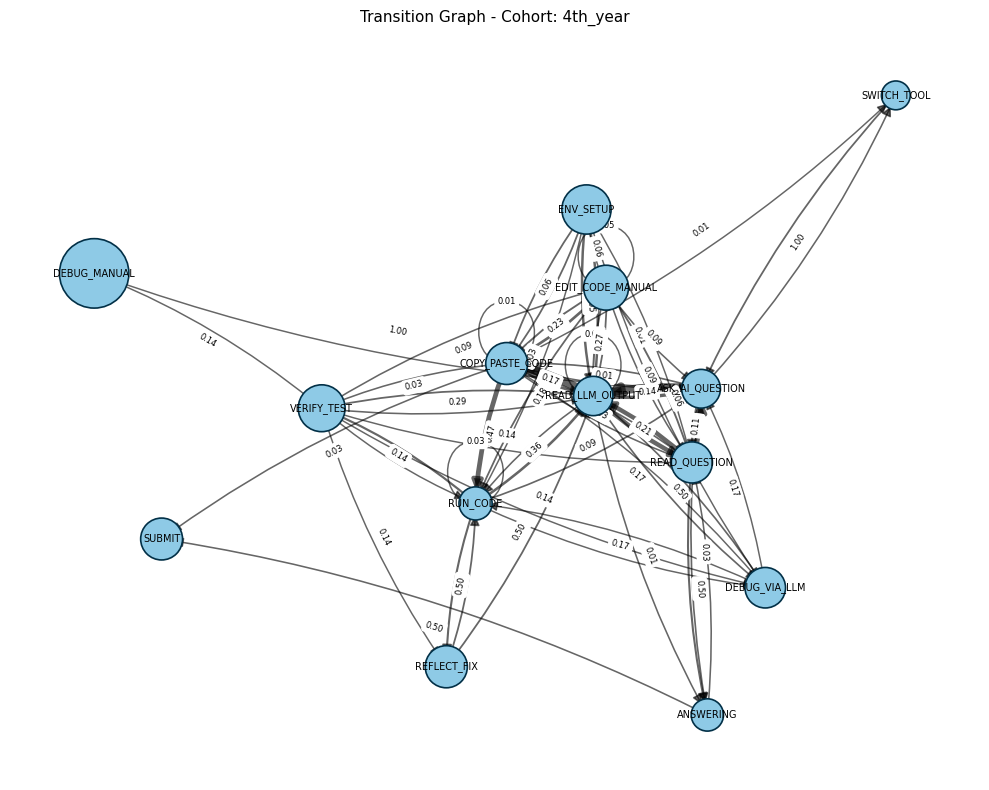

saved -> /Users/ucsc/Desktop/aca/Year_4_Sem_1/Research/llm/LLM-assistance-in-SE-Workflows/mnt/user-data/outputs/graphs/GROUP_cohort_1st_year.png


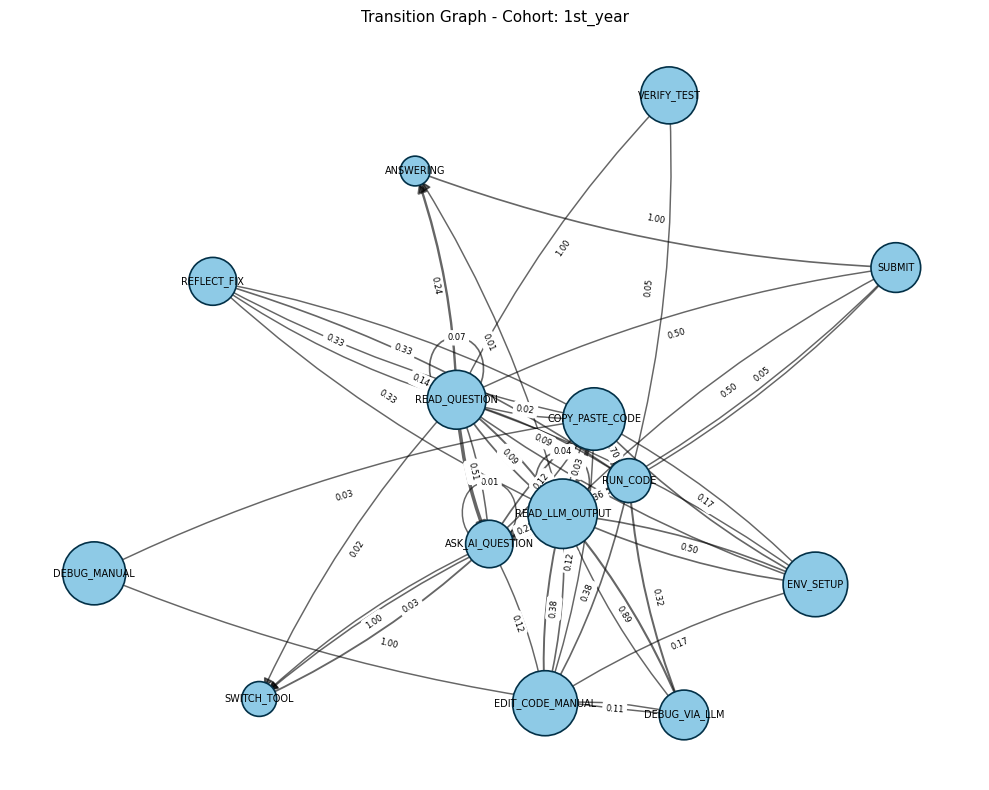

In [34]:
def sequences_for_group(df, sequences, group_col, group_value):
    ids = set(df.loc[df[group_col] == group_value, "Participant ID"])
    return [seq for key, seq in sequences.items() if key[0] in ids]

for cond in df["Condition"].dropna().unique():
    seq_list = sequences_for_group(df, sequences, "Condition", cond)
    save_path = os.path.join(OUT_DIR, f"GROUP_condition_{cond}.png")
    draw_transition_graph(seq_list, title=f"Transition Graph - Condition: {cond}", save_path=save_path)

for cohort in df["Cohort"].dropna().unique():
    seq_list = sequences_for_group(df, sequences, "Cohort", cohort)
    save_path = os.path.join(OUT_DIR, f"GROUP_cohort_{cohort}.png")
    draw_transition_graph(seq_list, title=f"Transition Graph - Cohort: {cohort}", save_path=save_path)

## 8. Loop detection - Step 8

Two approaches, both included:

1. **Automatic**: `networkx.simple_cycles` finds every elementary cycle
   actually present in a participant's graph (data-driven, no assumptions).
2. **Named-pattern matching**: checks each raw sequence for specific
   behavioural loops you care about (e.g. an AI-debug loop), using your
   actual Master Codes.

In [35]:
def find_cycles(G, max_len=6):
    # Returns list of cycles (as tuples of states) up to max_len.
    try:
        cycles = [c for c in nx.simple_cycles(G) if len(c) <= max_len]
    except Exception:
        cycles = []
    return cycles

for pid, G in participant_graphs.items():
    if G is None:
        continue
    cycles = find_cycles(G)
    if cycles:
        print(f"{pid}: {len(cycles)} cycle(s) found -> {cycles}")

S15: 70 cycle(s) found -> [['READ_QUESTION', 'ASK_AI_QUESTION', 'READ_LLM_OUTPUT', 'COPY_PASTE_CODE'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE', 'ENV_SETUP', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE', 'EDIT_CODE_MANUAL', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE', 'RUN_CODE', 'REFLECT_FIX', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE', 'RUN_CODE', 'VERIFY_TEST', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE', 'RUN_CODE', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE', 'RUN_CODE', 'DEBUG_VIA_LLM', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE', 'READ_LLM_OUTPUT'], ['READ_QUESTION', 'ASK_AI_QUESTION', 'COPY_PASTE_CODE'], ['READ_QUESTION', 'ASK_AI_QUESTION'], ['READ_QUESTION', 'READ_LLM_OUTPUT', 'COPY_PASTE_CODE', 'RUN_CODE', 'ASK_AI_QUESTION'

In [36]:
# Named pattern matching on raw sequences.
# Edit these to match the loops you actually want to track, using your
# real Master Codes (not shorthand, to avoid the WC/DB collisions).
NAMED_LOOPS = {
    "AI_debug_loop": ["DEBUG_VIA_LLM", "ASK_AI_QUESTION", "REFLECT_FIX", "RUN_CODE", "DEBUG_VIA_LLM"],
    "trial_error_loop": ["RUN_CODE", "DEBUG_MANUAL", "REFLECT_FIX", "RUN_CODE"],
    "direct_path": ["READ_QUESTION", "EDIT_CODE_MANUAL", "RUN_CODE", "SUBMIT"],
}

def contains_subsequence(states, pattern):
    # True if `pattern` appears as a contiguous run inside `states`.
    n, m = len(states), len(pattern)
    for i in range(n - m + 1):
        if states[i:i+m] == pattern:
            return True
    return False

loop_hits = []
for key, seq in sequences.items():
    states = [s for s, _ in seq]
    for loop_name, pattern in NAMED_LOOPS.items():
        if contains_subsequence(states, pattern):
            loop_hits.append({"sequence_key": key, "loop": loop_name})

loop_df = pd.DataFrame(loop_hits)
loop_df

""


## 9. Research-question style summaries - Step 9

Quick metrics you can group by `Condition` / `Cohort` for reporting.

In [37]:
ai_states = {"ASK_AI_QUESTION", "DEBUG_VIA_LLM", "READ_LLM_OUTPUT"}
df["is_ai_action"] = df["State Code"].isin(ai_states)

ai_consult_counts = (
    df[df["State Code"] == "ASK_AI_QUESTION"]
    .groupby(["Cohort", "Condition"])
    .size()
    .rename("ASK_AI_QUESTION_count")
)
print(ai_consult_counts)

Cohort    Condition
1st_year  with_AI      87
4th_year  with_AI      90
Name: ASK_AI_QUESTION_count, dtype: int64


In [38]:
seq_meta = []
for key, seq in sequences.items():
    total_dur = sum(d for _, d in seq if pd.notna(d))
    pid = key[0]
    row = df.loc[df["Participant ID"] == pid].iloc[0]
    seq_meta.append({
        "sequence_key": key,
        "Participant ID": pid,
        "Cohort": row["Cohort"],
        "Condition": row["Condition"],
        "total_duration_sec": total_dur,
        "n_actions": len(seq),
        "ends_in_submit": seq[-1][0] == "SUBMIT" if seq else False,
    })
seq_meta_df = pd.DataFrame(seq_meta)

seq_meta_df.groupby(["Cohort", "Condition"])[["total_duration_sec", "n_actions"]].mean()

,,total_duration_sec,n_actions
Cohort,Condition,,
1st_year,with_AI,193.575342,4.972603
4th_year,with_AI,240.185185,7.061728


In [39]:
verif = df.copy()
verif["verified"] = verif["Verification (Y/N)"].astype(str).str.upper().eq("Y")

verif_rate = (
    verif.groupby(["Cohort", "Condition"])["verified"]
    .mean()
    .rename("verification_rate")
)
print(verif_rate)

Cohort    Condition
1st_year  with_AI      0.005510
4th_year  with_AI      0.033217
Name: verification_rate, dtype: float64


## 10. Save all summary tables

Writes the transition counts/probabilities, loop hits, and sequence-level
metadata out as CSVs for use in your write-up.

In [42]:
out_csv_dir = OUT_DIR

overall_counts = transition_counts(list(sequences.values()))
overall_probs = transition_probabilities(overall_counts)
trans_df = pd.DataFrame([
    {"from": a, "to": b, "count": overall_counts[(a, b)], "probability": overall_probs[(a, b)]}
    for (a, b) in overall_counts
]).sort_values(["from", "probability"], ascending=[True, False])

trans_df.to_csv(f"{out_csv_dir}/transition_counts_probabilities.csv", index=False)
loop_df.to_csv(f"{out_csv_dir}/loop_hits.csv", index=False)
seq_meta_df.to_csv(f"{out_csv_dir}/sequence_summary.csv", index=False)

print("Saved: transition_counts_probabilities.csv, loop_hits.csv, sequence_summary.csv")
trans_df.head(15)

Saved: transition_counts_probabilities.csv, loop_hits.csv, sequence_summary.csv


,from,to,count,probability
7,ANSWERING,SUBMIT,5,0.714286
60,ANSWERING,READ_QUESTION,2,0.285714
0,ASK_AI_QUESTION,READ_LLM_OUTPUT,145,0.852941
6,ASK_AI_QUESTION,READ_QUESTION,12,0.070588
36,ASK_AI_QUESTION,COPY_PASTE_CODE,5,0.029412
24,ASK_AI_QUESTION,SWITCH_TOOL,3,0.017647
59,ASK_AI_QUESTION,ANSWERING,3,0.017647
62,ASK_AI_QUESTION,ASK_AI_QUESTION,1,0.005882
66,ASK_AI_QUESTION,RUN_CODE,1,0.005882
20,COPY_PASTE_CODE,RUN_CODE,57,0.542857
